# Web scraping

In [ ]:
# Update package list and install necessary dependencies
!apt-get update
!apt-get install -y wget unzip libvulkan1

# Download and install Google Chrome
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb
!apt-get install -f -y

# Install xvfb for virtual framebuffer support
!apt-get install -y xvfb

# Install selenium and chromedriver-autoinstaller
!pip install selenium chromedriver-autoinstaller

# Automatically install the correct version of ChromeDriver
import chromedriver_autoinstaller
chromedriver_autoinstaller.install()

# Configure Selenium with Chrome options
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-dev-shm-usage")

# Initialize the WebDriver
driver = webdriver.Chrome(options=chrome_options)

# Open Google and print the title of the page
driver.get('https://google.com')
print(driver.title)
driver.quit()

In [ ]:
%%shell
# Ubuntu no longer distributes chromium-browser outside of snap
#
# Proposed solution: https://askubuntu.com/questions/1204571/how-to-install-chromium-without-snap

# Add debian buster
cat > /etc/apt/sources.list.d/debian.list <<'EOF'
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster.gpg] http://deb.debian.org/debian buster main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster-updates.gpg] http://deb.debian.org/debian buster-updates main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-security-buster.gpg] http://deb.debian.org/debian-security buster/updates main
EOF

# Add keys
apt-key adv --keyserver keyserver.ubuntu.com --recv-keys DCC9EFBF77E11517
apt-key adv --keyserver keyserver.ubuntu.com --recv-keys 648ACFD622F3D138
apt-key adv --keyserver keyserver.ubuntu.com --recv-keys 112695A0E562B32A

apt-key export 77E11517 | gpg --dearmour -o /usr/share/keyrings/debian-buster.gpg
apt-key export 22F3D138 | gpg --dearmour -o /usr/share/keyrings/debian-buster-updates.gpg
apt-key export E562B32A | gpg --dearmour -o /usr/share/keyrings/debian-security-buster.gpg

# Prefer debian repo for chromium* packages only
# Note the double-blank lines between entries
cat > /etc/apt/preferences.d/chromium.pref << 'EOF'
Package: *
Pin: release a=eoan
Pin-Priority: 500


Package: *
Pin: origin "deb.debian.org"
Pin-Priority: 300


Package: chromium*
Pin: origin "deb.debian.org"
Pin-Priority: 700
EOF

# Install chromium and chromium-driver
apt-get update
apt-get install chromium chromium-driver

# Install selenium
pip install selenium
pip install webdriver_manager
import pandas as pd
import numpy as np


In [ ]:
!git clone https://github.com/abachaa/MedQuAD.git

Cloning into 'MedQuAD'...
remote: Enumerating objects: 11310, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 11310 (delta 7), reused 4 (delta 4), pack-reused 11300 (from 1)
Receiving objects: 100% (11310/11310), 11.01 MiB | 12.68 MiB/s, done.
Resolving deltas: 100% (6807/6807), done.


In [ ]:
import os
os.chdir('/content/MedQuAD')
os.listdir('/content/MedQuAD')


['4_MPlus_Health_Topics_QA',
 '.git',
 '2_GARD_QA',
 '7_SeniorHealth_QA',
 '3_GHR_QA',
 '12_MPlusHerbsSupplements_QA',
 '5_NIDDK_QA',
 'QA-TestSet-LiveQA-Med-Qrels-2479-Answers.zip',
 'LICENSE.txt',
 '9_CDC_QA',
 '6_NINDS_QA',
 '10_MPlus_ADAM_QA',
 '11_MPlusDrugs_QA',
 'readme.txt',
 '1_CancerGov_QA',
 '8_NHLBI_QA_XML']

In [ ]:
import os
import random
import json
import xml.etree.ElementTree as ET

# Define the parent directory where XML files are stored
data_dir = "/content/MedQuAD"

# List of subfolders
folders = [
    "1_CancerGov_QA", "2_GARD_QA", "3_GHR_QA", "4_MPlus_Health_Topics_QA",
    "5_NIDDK_QA", "6_NINDS_QA", "7_SeniorHealth_QA", "8_NHLBI_QA_XML", "9_CDC_QA"
]

# Dictionary to store extracted Q&A data grouped by URL
qa_data_dict = {}

# Loop through each folder and process XML files
for folder in folders:
    folder_path = os.path.join(data_dir, folder)

    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".xml"):
                file_path = os.path.join(folder_path, file)

                try:
                    # Parse XML
                    tree = ET.parse(file_path)
                    root = tree.getroot()

                    # Extract URL
                    url = root.attrib.get("url")

                    # Extract all question-answer pairs for this URL
                    if url and "https://rarediseases.info.nih.gov/gard/" not in url:
                        if url not in qa_data_dict:
                            qa_data_dict[url] = []  # Initialize list for this URL

                        for qa_pair in root.findall(".//QAPair"):
                            question = qa_pair.find("Question").text if qa_pair.find("Question") is not None else "No Question"
                            answer = qa_pair.find("Answer").text if qa_pair.find("Answer") is not None else "No Answer"

                            # Store each Q&A pair under the respective URL
                            qa_data_dict[url].append({"question": question, "answer": answer})

                except ET.ParseError:
                    print(f"Skipping invalid XML file: {file_path}")

# Convert the dictionary into a list format for JSON storage
qa_data_list = [{"url": url, "qa_pairs": qa_pairs} for url, qa_pairs in qa_data_dict.items()]

# Randomly select 2000 Q&A pairs while maintaining the structure
sampled_data = random.sample(qa_data_list, min(3000, len(qa_data_list)))

# Save to a JSON file
output_file = "/content/filtered_qa_2.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(sampled_data, f, indent=4, ensure_ascii=False)

print(f"✅ Extracted {len(sampled_data)} unique URLs with Q&A pairs and saved to {output_file}.")


✅ Extracted 2802 unique URLs with Q&A pairs and saved to /content/filtered_qa_2.json.


In [ ]:
import json

# Load the extracted Q&A data
qa_data_path = "/content/filtered_qa_2.json"
with open(qa_data_path, "r", encoding="utf-8") as f:
    qa_data = json.load(f)

# Print the first 5 Q&A pairs in JSON format
print(json.dumps(qa_data[:5], indent=4, ensure_ascii=False))  # Adjust the number if needed


[
    {
        "url": "https://www.nlm.nih.gov/medlineplus/botox.html",
        "qa_pairs": [
            {
                "question": "Do you have information about Botox",
                "answer": "Summary : Botox is a drug made from a toxin produced by the bacterium Clostridium botulinum. It's the same toxin that causes a life-threatening type of food poisoning called botulism. Doctors use it in small doses to treat health problems, including       - Temporary smoothing of facial wrinkles and improving your appearance    - Severe underarm sweating     - Cervical dystonia - a neurological disorder that causes severe neck and shoulder muscle contractions     - Blepharospasm - uncontrollable blinking     - Strabismus - misaligned eyes     - Chronic migraine    - Overactive bladder       Botox injections work by weakening or paralyzing certain muscles or by blocking certain nerves. The effects last about three to twelve months, depending on what you are treating. The most common side

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import json
import shutil

# Define paths
qa_data_path = "/content/filtered_qa_2.json"
drive_save_path = "/content/drive/My Drive/filtered_qa_2.json"  # Change the path if needed

# Copy file to Google Drive
shutil.copy(qa_data_path, drive_save_path)
print(f"✅ File saved to {drive_save_path}")

# Load and print the first 5 Q&A pairs
with open(drive_save_path, "r", encoding="utf-8") as f:
    qa_data = json.load(f)



Mounted at /content/drive
✅ File saved to /content/drive/My Drive/filtered_qa_2.json


In [ ]:
import os
import json
import random
import time
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# Define input/output file paths
input_file = "/content/filtered_qa_2.json"
output_file = "/content/scraped_qa_content_2.json"

# Load JSON data
try:
    with open(input_file, "r", encoding="utf-8") as f:
        qa_data = json.load(f)
except FileNotFoundError:
    print(f"Error: {input_file} not found.")
    exit(1)
except json.JSONDecodeError:
    print(f"Error: {input_file} is not a valid JSON file.")
    exit(1)

# Extract URLs
ordered_urls = [item["url"] for item in qa_data if "url" in item and "qa_pairs" in item]

# Function for static scraping
def extract_static_content(url):
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        content_tags = soup.find_all(['article', 'section', 'p'])
        extracted_text = {tag.get_text(strip=True) for tag in content_tags if tag}
        return "\n".join(extracted_text) if extracted_text else "No relevant content found."
    except requests.exceptions.RequestException as e:
        return f"Error fetching {url}: {e}"

# Function for dynamic scraping with interaction
def extract_dynamic_content(url):
    options = Options()
    options.add_argument("--headless")
    options.add_argument("--disable-gpu")
    options.add_argument("--window-size=1920x1080")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")

    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

    try:
        driver.get(url)
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.TAG_NAME, "body"))
        )

        # Try expanding hidden content (e.g., accordions or buttons)
        expandable_elements = driver.find_elements(By.XPATH, "//button[contains(@aria-expanded, 'false')] | //div[@role='button']")
        for elem in expandable_elements:
            try:
                driver.execute_script("arguments[0].scrollIntoView(true);", elem)
                time.sleep(0.3)
                elem.click()
                time.sleep(0.5)
            except Exception:
                continue

        # Parse updated page content
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        content_tags = soup.find_all(['article', 'section', 'p'])
        extracted_text = {tag.get_text(strip=True) for tag in content_tags if tag}

    except Exception as e:
        extracted_text = {f"Error loading {url}: {e}"}
    finally:
        driver.quit()

    return "\n".join(extracted_text) if extracted_text else "No relevant content found."

# Scrape all URLs
scraped_data = []
for index, url in enumerate(ordered_urls, start=1):
    print(f"({index}/{len(ordered_urls)}) Scraping: {url}")
    content = extract_dynamic_content(url) if "medlineplus.gov/genetics" in url else extract_static_content(url)

    for item in qa_data:
        if item["url"] == url:
            scraped_data.append({
                "url": url,
                "qa_pairs": item["qa_pairs"],
                "content": content
            })
            break

    time.sleep(0.5)  # Be kind to servers

# Save to output JSON
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(scraped_data, f, indent=4, ensure_ascii=False)

print(f"\n✅ Scraping completed. Data saved to {output_file}.")


(1/2802) Scraping: https://www.nlm.nih.gov/medlineplus/botox.html
(2/2802) Scraping: https://www.nlm.nih.gov/medlineplus/huntingtonsdisease.html
(3/2802) Scraping: http://www.ninds.nih.gov/disorders/chronic_pain/chronic_pain.htm
(4/2802) Scraping: https://www.nlm.nih.gov/medlineplus/gaylesbianbisexualandtransgenderhealth.html
(5/2802) Scraping: https://ghr.nlm.nih.gov/condition/laron-syndrome
(6/2802) Scraping: https://www.nlm.nih.gov/medlineplus/h1n1fluswineflu.html
(7/2802) Scraping: https://www.nlm.nih.gov/medlineplus/endoflifeissues.html
(8/2802) Scraping: https://ghr.nlm.nih.gov/condition/pendred-syndrome
(9/2802) Scraping: https://ghr.nlm.nih.gov/condition/cherubism
(10/2802) Scraping: https://ghr.nlm.nih.gov/condition/ellis-van-creveld-syndrome
(11/2802) Scraping: https://ghr.nlm.nih.gov/condition/familial-hemiplegic-migraine
(12/2802) Scraping: http://www.ninds.nih.gov/disorders/spasticity/spasticity.htm
(13/2802) Scraping: http://www.cdc.gov/nczved/divisions/dfbmd/diseases/mar

In [ ]:
output_file = "/content/drive/My Drive/scraped_qa_content_2.json"

# Save scraped data to JSON file in Google Drive
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(scraped_data, f, indent=4, ensure_ascii=False)

print(f"\n✅ Scraping completed. Data saved to {output_file}.")


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_json('/content/drive/My Drive/scraped_qa_content_2_final.json')
df.head()

,url,qa_pairs,content
0,https://www.nlm.nih.gov/medlineplus/botox.html,[{'question': 'Do you have information about B...,SummaryBotox is a drug made from a toxin produ...
1,https://www.nlm.nih.gov/medlineplus/huntington...,[{'question': 'What is (are) Huntington's Dise...,\nClinical TrialsClinicalTrials.gov: Huntingto...
2,http://www.ninds.nih.gov/disorders/chronic_pai...,"[{'question': 'What is (are) Chronic Pain ?', ...",Error fetching http://www.ninds.nih.gov/disord...
3,https://www.nlm.nih.gov/medlineplus/gaylesbian...,"[{'question': 'What is (are) Gay, Lesbian, Bis...",Error fetching https://www.nlm.nih.gov/medline...
4,https://ghr.nlm.nih.gov/condition/laron-syndrome,[{'question': 'What is (are) Laron syndrome ?'...,\nGH-R deficiencyGrowth hormone insensitivity ...


# Cleaning

In [ ]:
import re
from bs4 import BeautifulSoup

def clean_medical_text(html_content: str) -> str:
    soup = BeautifulSoup(html_content, "html.parser")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    text = soup.get_text(separator=' ')
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http[s]?://\S+', '', text)
    text = text.replace("â€™", "'").replace("â€œ", '"').replace("â€", '"')

    # 👇 Add space between lowercase-uppercase (e.g., SummaryBotox → Summary Botox)
    text = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', text)

    # (Optional) 👇 Add space between letters and numbers (e.g., Botox123 → Botox 123)
    text = re.sub(r'(?<=[a-zA-Z])(?=\d)', ' ', text)
    text = re.sub(r'(?<=\d)(?=[a-zA-Z])', ' ', text)

    lines = text.split('.')
    seen = set()
    unique_lines = []
    for line in lines:
        if line not in seen:
            unique_lines.append(line)
            seen.add(line)
    cleaned_text = '. '.join(unique_lines)

    text = re.sub(r'[^\w\s,.\-]', '', cleaned_text)

    return text.strip()

# Re-run the function after updating it
df['cleaned_text'] = df['content'].apply(clean_medical_text)


In [ ]:
df.head()

,url,qa_pairs,content,cleaned_text
0,https://www.nlm.nih.gov/medlineplus/botox.html,[{'question': 'Do you have information about B...,SummaryBotox is a drug made from a toxin produ...,Summary Botox is a drug made from a toxin prod...
1,https://www.nlm.nih.gov/medlineplus/huntington...,[{'question': 'What is (are) Huntington's Dise...,\nClinical TrialsClinicalTrials.gov: Huntingto...,Clinical Trials Clinical Trials. gov Huntingto...
4,https://ghr.nlm.nih.gov/condition/laron-syndrome,[{'question': 'What is (are) Laron syndrome ?'...,\nGH-R deficiencyGrowth hormone insensitivity ...,GH-R deficiency Growth hormone insensitivity s...
5,https://www.nlm.nih.gov/medlineplus/h1n1fluswi...,[{'question': 'What is (are) H1N1 Flu (Swine F...,\nStart HereAbout Swine/Variant Flu(Centers fo...,Start Here About SwineVariant FluCenters for D...
6,https://www.nlm.nih.gov/medlineplus/endoflifei...,[{'question': 'Do you have information about E...,\nOn this pageBasicsSummaryStart HereLearn Mor...,On this page Basics Summary Start Here Learn M...


In [ ]:
df.to_csv('/content/drive/My Drive/cleaned_df.csv', index=False)


In [ ]:
import pandas as pd

cleaned_df = pd.read_csv('/content/drive/My Drive/cleaned_df.csv')


In [ ]:
cleaned_df.head(10)

,url,qa_pairs,content,cleaned_text
0,https://www.nlm.nih.gov/medlineplus/botox.html,[{'question': 'Do you have information about B...,SummaryBotox is a drug made from a toxin produ...,Summary Botox is a drug made from a toxin prod...
1,https://www.nlm.nih.gov/medlineplus/huntington...,"[{'question': ""What is (are) Huntington's Dise...",\nClinical TrialsClinicalTrials.gov: Huntingto...,Clinical Trials Clinical Trials. gov Huntingto...
2,https://ghr.nlm.nih.gov/condition/laron-syndrome,[{'question': 'What is (are) Laron syndrome ?'...,\nGH-R deficiencyGrowth hormone insensitivity ...,GH-R deficiency Growth hormone insensitivity s...
3,https://www.nlm.nih.gov/medlineplus/h1n1fluswi...,[{'question': 'What is (are) H1N1 Flu (Swine F...,\nStart HereAbout Swine/Variant Flu(Centers fo...,Start Here About SwineVariant FluCenters for D...
4,https://www.nlm.nih.gov/medlineplus/endoflifei...,[{'question': 'Do you have information about E...,\nOn this pageBasicsSummaryStart HereLearn Mor...,On this page Basics Summary Start Here Learn M...
5,https://ghr.nlm.nih.gov/condition/pendred-synd...,[{'question': 'What is (are) Pendred syndrome ...,\nAutosomal recessive sensorineural hearing im...,Autosomal recessive sensorineural hearing impa...
6,https://ghr.nlm.nih.gov/condition/cherubism,"[{'question': 'What is (are) cherubism ?', 'an...",\nAn official website of the United States gov...,An official website of the United States gover...
7,https://ghr.nlm.nih.gov/condition/ellis-van-cr...,[{'question': 'What is (are) Ellis-van Creveld...,Ellis-van Creveld syndrome can be caused by mu...,Ellis-van Creveld syndrome can be caused by mu...
8,https://ghr.nlm.nih.gov/condition/familial-hem...,[{'question': 'What is (are) familial hemipleg...,\nRelated Health TopicsGenetic DisordersMigrai...,Related Health Topics Genetic Disorders Migrai...
9,http://www.niddk.nih.gov/health-information/he...,[{'question': 'What is (are) Childhood Nephrot...,"\n1. Downie ML, Gallibois C, Parekh RS, Noone ...","1. Downie ML, Gallibois C, Parekh RS, Noone D..."


In [ ]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Chunks

In [ ]:
import pandas as pd
import spacy
from transformers import AutoTokenizer

# Load lightweight spaCy pipeline for sentence tokenization
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")  # Only sentence segmentation, no other heavy tasks

# Use BioBERT tokenizer instead of BERT
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

# Read your DataFrame (make sure you upload the CSV in Colab)
cleaned_df = pd.read_csv('/content/drive/My Drive/cleaned_df.csv')

# Set token limits
max_tokens = 1000

# Chunking function (No overlap)
def chunk_text(text, max_tokens=1000):
    # Use spaCy for sentence tokenization (fast and light)
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents]

    chunks = []
    current_chunk = []
    current_length = 0

    for sentence in sentences:
        # Tokenize sentence with BioBERT tokenizer
        sentence_tokens = tokenizer.tokenize(sentence)
        sentence_length = len(sentence_tokens)

        # If adding this sentence exceeds the max token limit, create a new chunk
        if current_length + sentence_length > max_tokens:
            chunks.append(" ".join(current_chunk))  # Append the current chunk
            current_chunk = [sentence]  # Start a new chunk with the current sentence
            current_length = sentence_length  # Reset length to current sentence's length
        else:
            current_chunk.append(sentence)  # Add the sentence to the current chunk
            current_length += sentence_length  # Update the length of the current chunk

    # Append the last chunk if any sentences are left
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

# Apply chunking
chunked_rows = []
for _, row in cleaned_df.iterrows():
    try:
        chunks = chunk_text(str(row["cleaned_text"]), max_tokens)
        for chunk in chunks:
            chunked_rows.append({
                "url": row["url"],
                "qa_pairs": row["qa_pairs"],
                "content": row["content"],
                "chunked_cleaned_text": chunk
            })
    except Exception as e:
        print(f"Error processing row: {e}")

# Create new DataFrame with chunked text
chunked_df = pd.DataFrame(chunked_rows)

# Save the chunked output (optional)
chunked_df.to_csv("/content/drive/My Drive/chunked_cleaned_df.csv", index=False)

# Display a few rows of the chunked DataFrame
chunked_df.head()


,url,qa_pairs,content,chunked_cleaned_text
0,https://www.nlm.nih.gov/medlineplus/botox.html,[{'question': 'Do you have information about B...,SummaryBotox is a drug made from a toxin produ...,Summary Botox is a drug made from a toxin prod...
1,https://www.nlm.nih.gov/medlineplus/botox.html,[{'question': 'Do you have information about B...,SummaryBotox is a drug made from a toxin produ...,An official website of the United States gover...
2,https://www.nlm.nih.gov/medlineplus/huntington...,"[{'question': ""What is (are) Huntington's Dise...",\nClinical TrialsClinicalTrials.gov: Huntingto...,Clinical Trials Clinical Trials. gov Huntingto...
3,https://www.nlm.nih.gov/medlineplus/huntington...,"[{'question': ""What is (are) Huntington's Dise...",\nClinical TrialsClinicalTrials.gov: Huntingto...,Medline Plus also links to health information ...
4,https://ghr.nlm.nih.gov/condition/laron-syndrome,[{'question': 'What is (are) Laron syndrome ?'...,\nGH-R deficiencyGrowth hormone insensitivity ...,GH-R deficiency Growth hormone insensitivity s...


In [ ]:
chunked_df.iloc[0,3]

'Summary Botox is a drug made from a toxin produced by the bacterium Clostridium botulinum. Its the same toxin that causes a life-threatening type of food poisoning calledbotulism. Doctors use it in small doses to treat health problems, includingTemporary smoothing of facialwrinklesand improving your appearance Severe underarm sweating Cervical dystonia - a neurological disorder that causes severe neck and shoulder muscle contractions Blepharospasm - uncontrollable blinking Strabismus - misaligned eyes Chronic migraine Overactive bladder Botox injections work by weakening or paralyzing certain muscles or by blocking certain nerves. The effects last about three to twelve months, depending on what you are treating. The most common side effects are pain, swelling, or bruising at the injection site. You could also have flu-like symptoms, headache, and upset stomach. Injections in the face may also cause temporary drooping eyelids. You should not use Botox if you are pregnant or breastfeedi

In [ ]:
chunked_df.iloc[1,3]

'mers Medline Plus links to health information from the National Institutes of Health and other federal government agencies. The information on this site should not be used as a substitute for professional medical care or advice. Contact a health care provider if you have questions about your health. An official website of the United States government Find an Expert Find a DermatologistAmerican Academy of Dermatology Learn More Botox InjectionsMayo Foundation for Medical Education and ResearchBotulinum Neurotoxin InjectionsDystonia Medical Research FoundationBotulinum Toxin BotoxVisual DXBotulinum Toxin Botox for Facial WrinklesAmerican Academy of OphthalmologyBotulinum Toxin Injections A Treatment for Muscle SpasmsAmerican Academy of Family PhysiciansAlso in Spanish Botulinum Toxin Therapy OverviewAmerican Academy of DermatologyCounterfeit Version of Botox Found in the United StatesFood and Drug AdministrationInjectables and Wrinkle Treatment Understanding Types of Treatments for Faci

In [ ]:
chunked_df = pd.read_csv('/content/drive/My Drive/chunked_cleaned_df.csv')

In [ ]:
chunked_df.shape

(7385, 4)

# Embeddings and Vector Database

In [ ]:
!pip install faiss-cpu
!pip install transformers
!pip install sentence-transformers
!pip install langchain langchain-community langchain-huggingface faiss-cpu sentence-transformers

In [ ]:

# Step 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 3: Import libraries
import pandas as pd
import os
from langchain_community.vectorstores.faiss import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.document_loaders import DataFrameLoader

# Step 4: Load your chunked dataframe
chunked_df = pd.read_csv('/content/drive/My Drive/chunked_cleaned_df.csv')

# Step 5: Convert the DataFrame into LangChain documents
loader = DataFrameLoader(chunked_df, page_content_column="chunked_cleaned_text")
documents = loader.load()

# Step 6: Initialize the GTE embedding model
embedding_model = HuggingFaceEmbeddings(model_name="thenlper/gte-large")

# Step 7: Create FAISS vectorstore from documents
vectorstore = FAISS.from_documents(documents, embedding_model)

# Step 8: Save FAISS index and metadata to your Google Drive folder
save_path = "/content/drive/MyDrive/NLP_PROJECT/FINAL_FAISS_STORE_REBUILT"
os.makedirs(save_path, exist_ok=True)
vectorstore.save_local(save_path)

print("✅ FAISS index + metadata saved to:", save_path)


# RAG

In [ ]:
# When loading your FAISS
embedding_model = HuggingFaceEmbeddings(model_name="thenlper/gte-base")
print("Embedding size:", len(embedding_model.embed_query("test")))


Embedding size: 768


In [ ]:
pip install langchain langchain-community faiss-cpu ollama sentence-transformers

In [ ]:
import textwrap
from langchain_community.vectorstores.faiss import FAISS
from langchain.chains import RetrievalQA
from langchain.llms import Ollama
from langchain.embeddings import HuggingFaceEmbeddings

def initialize_rag_system(faiss_index_path, model_name="llama3.1:8b", embedding_model_name="thenlper/gte-large", k=5):
    # Load embedding model
    embedding_model = HuggingFaceEmbeddings(model_name=embedding_model_name)

    # Load FAISS vector store with embeddings
    vectorstore = FAISS.load_local(faiss_index_path, embeddings=embedding_model, allow_dangerous_deserialization=True)

    # Convert FAISS store into a retriever
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})

    # Load local LLM via Ollama
    llm = Ollama(model=model_name)

    # Create RAG chain
    return RetrievalQA.from_chain_type(llm=llm, retriever=retriever)

def generate_response(qa_chain, query, width=80):
    response = qa_chain.run(query)
    wrapped_response = textwrap.fill(response, width=width)
    print("\n" + wrapped_response)

# ✅ Updated FAISS index path and embedding model
faiss_index_path = "/Users/patial31/Desktop/NLP PROJECT_2/FINAL_FAISS_STORE_REBUILT"
qa_chain = initialize_rag_system(faiss_index_path)

# 🔍 Example query
query1 = "What is isolated growth hormone deficiency?"
generate_response(qa_chain, query1)



Isolated growth hormone deficiency (IGHD) is a rare condition characterized by
low levels or complete absence of growth hormone (GH) in the body. It affects
the production of GH, which plays a crucial role in regulating growth and
development during childhood and adolescence.  There are four types of IGHD
differentiated by the severity of the condition, the gene involved, and the
inheritance pattern:  1. **Type IA**: Caused by mutations in the GHRH (growth
hormone-releasing hormone) receptor or its ligand, GHRH. Inherited in an
autosomal dominant pattern. 2. **Type IB**: Caused by mutations in the GH1 gene
that encodes growth hormone itself. Inherited in an autosomal recessive pattern.
3. **Type II**: Characterized by a mild deficiency of growth hormone, often with
normal growth velocity and delayed closure of epiphyseal plates. The exact
genetic cause is not well understood. 4. **Type III** (also known as **Laron
Syndrome**): Caused by mutations in the GHR (growth hormone receptor) g

In [ ]:
query2 = "What are the treatments for Primary Sclerosing Cholangitis ?"
generate_response(qa_chain, query2)


The treatments for Primary Sclerosing Cholangitis (PSC) focus on managing
symptoms, preventing complications, and slowing disease progression. While there
is no cure for PSC, treatment options may include:  1. **Medications**: To
manage symptoms such as itching, fatigue, and abdominal pain. 2.
**Ursodeoxycholic acid (UDCA)**: A medication that helps reduce bile acid
production and can slow disease progression. 3. **Immunosuppressive therapy**:
Medications like azathioprine or cyclosporine may be used to suppress the immune
system's attack on the bile ducts. 4. **Bile acid sequestrants**: Medications
that bind to bile acids in the gut, reducing their concentration and helping
manage symptoms. 5. **Liver transplantation**: In advanced cases where liver
damage is severe, a liver transplant may be necessary.  It's essential for
individuals with PSC to work closely with their healthcare provider to develop a
personalized treatment plan and monitor disease progression.


In [ ]:
import time
import textwrap
from langchain_community.vectorstores import FAISS
from langchain.chains import RetrievalQA
from langchain.llms import Ollama
from langchain.embeddings import HuggingFaceEmbeddings

# Step 1: Load everything
print("Loading embeddings and database...")
start = time.time()
embedding_model = HuggingFaceEmbeddings(model_name="thenlper/gte-large")

# Load FAISS vector store with embeddings
faiss_index_path = "/Users/patial31/Desktop/NLP PROJECT_2/FINAL_FAISS_STORE_REBUILT"  # Update path as per your system
db = FAISS.load_local(faiss_index_path, embeddings=embedding_model, allow_dangerous_deserialization=True)
print(f"Loaded embeddings + FAISS database in {time.time() - start:.2f} seconds.\n")

# Step 2: Setup retriever and LLM
print("Setting up retriever and LLM...")
start = time.time()
retriever = db.as_retriever(search_kwargs={"k": 3})

# Load local LLM via Ollama
llm = Ollama(model="llama3.1:8b")

# Create RAG chain
qa_chain = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)
print(f"Retriever and LLM setup done in {time.time() - start:.2f} seconds.\n")

# Step 3: Define your query
query1 = "What is isolated growth hormone deficiency?"
print(f"Query: {query1}")

# Step 4: Start full query timing
full_start = time.time()

# Step 5: Retrieve documents
print("\nRetrieving documents...")
retrieval_start = time.time()
retrieved_docs = retriever.get_relevant_documents(query1)
print(f"Retrieved {len(retrieved_docs)} documents in {time.time() - retrieval_start:.2f} seconds.")

# (Optional: Show first 3 retrieved docs)
for i, doc in enumerate(retrieved_docs[:3]):
    print(f"\n--- Retrieved Doc {i+1} ---\n{doc.page_content[:300]}...\n")

# Step 6: Generate answer
print("\nGenerating answer with LLM...")
generation_start = time.time()
response = qa_chain.run(query1)
answer = response
print(f"Answer generated in {time.time() - generation_start:.2f} seconds.\n")

# Step 7: Final output
print(f"Full query process completed in {time.time() - full_start:.2f} seconds.\n")
print("=== FINAL ANSWER ===\n")
print(answer)


Loading embeddings and database...
Loaded embeddings + FAISS database in 26.28 seconds.

Setting up retriever and LLM...
Retriever and LLM setup done in 0.23 seconds.

Query: What is isolated growth hormone deficiency?

Retrieving documents...
Retrieved 3 documents in 0.18 seconds.

--- Retrieved Doc 1 ---
Learn more about the genes associated with Isolated growth hormone deficiency BTKGH 1 GHRHR Isolated growth hormone deficiency is a condition caused by a severe shortage or absence of growth hormone. Growth hormone is a protein that is necessary for the normal growth of the bodys bones and tissues. ...


--- Retrieved Doc 2 ---
01797. Citation on Pub Med Mullis PE. Genetics of isolated growth hormone deficiency. J Clin Res Pediatr Endocrinol. 20102252-62. 4274jcrpe. v 2 i 2. 52. Epub 2010 May 1. Citation on Pub Medor Free article on Pub Med Central Seaver LH, Irons M American College of Medical Genetics ACMG Professional P...


--- Retrieved Doc 3 ---
In these individuals, the cause 

/var/folders/vj/hr83jn9s1wd2d2sqrtqny9nr0000gn/T/ipykernel_38483/572781152.py:40: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = retriever.get_relevant_documents(query1)


Answer generated in 100.99 seconds.

Full query process completed in 101.17 seconds.

=== FINAL ANSWER ===

Isolated growth hormone deficiency (IGHD) is a rare condition characterized by low levels of growth hormone (GH), which is essential for growth and development in children and adolescents. This condition occurs when the pituitary gland does not produce enough GH, leading to short stature or delayed puberty.

There are several types of IGHD, each with different causes and inheritance patterns:

1. **Type IA**: Caused by mutations in the GHRHR gene (growth hormone-releasing hormone receptor), which is inherited in an autosomal recessive pattern.
2. **Type IB**: Also caused by mutations in the GHRHR gene, but with a different inheritance pattern (autosomal dominant).
3. **Type II**: Resulting from new mutations in the GH1 gene or from mutations in the GHRHR gene, which is inherited in an autosomal dominant pattern.
4. **Type III**: Caused by mutations in the BTK gene (Bruton's tyros

In [ ]:
import pandas as pd
import ast

# Read your original dataframe
df = pd.read_csv("/Users/patial31/Desktop/NLP PROJECT_2/cleaned_df_2.csv")

# Function to safely parse qa_pairs JSON string
def parse_qa_pairs(qa_string):
    try:
        return ast.literal_eval(qa_string)
    except Exception as e:
        print(f"Error parsing qa_pairs: {e}")
        return []

# Create a list to store the expanded rows
rows = []

# Loop over each row in the original dataframe
for idx, row in df.iterrows():
    qa_pairs = parse_qa_pairs(row['qa_pairs'])  # Parse the JSON string
    for qa in qa_pairs:
        rows.append({
            'question': qa.get('question', ''),
            'correct_answer': qa.get('answer', ''),
            'generated_answer': ''  # Leave empty for now
        })

# Create the new dataframe
rag_generated_answer_df = pd.DataFrame(rows)

# Quick check
rag_generated_answer_df.head()


,question,correct_answer,generated_answer
0,Do you have information about Botox,Summary : Botox is a drug made from a toxin pr...,
1,What is (are) Huntington's Disease ?,Huntington's disease (HD) is an inherited dise...,
2,What is (are) Laron syndrome ?,Laron syndrome is a rare form of short stature...,
3,How many people are affected by Laron syndrome ?,Laron syndrome is a rare disorder. About 350 p...,
4,What are the genetic changes related to Laron ...,Laron syndrome is caused by mutations in the G...,


In [ ]:
rag_generated_answer_df.head(10)

,question,correct_answer,generated_answer
0,Do you have information about Botox,Summary : Botox is a drug made from a toxin pr...,
1,What is (are) Huntington's Disease ?,Huntington's disease (HD) is an inherited dise...,
2,What is (are) Laron syndrome ?,Laron syndrome is a rare form of short stature...,
3,How many people are affected by Laron syndrome ?,Laron syndrome is a rare disorder. About 350 p...,
4,What are the genetic changes related to Laron ...,Laron syndrome is caused by mutations in the G...,
5,Is Laron syndrome inherited ?,Most cases of Laron syndrome are inherited in ...,
6,What are the treatments for Laron syndrome ?,These resources address the diagnosis or manag...,
7,What is (are) H1N1 Flu (Swine Flu) ?,Swine flu is an infection caused by a virus. I...,
8,Do you have information about End of Life Issues,Summary : Planning for the end of life can be ...,
9,What is (are) Pendred syndrome ?,Pendred syndrome is a disorder typically assoc...,


In [ ]:
rag_generated_answer_df.shape

(7727, 3)

In [ ]:
!pip install datasets
!pip install bert-score
!pip install evaluate

In [ ]:
pip install absl-py


In [ ]:
pip install nltk rouge_score bert-score datasets langchain sentence-transformers

In [ ]:
rag_generated_answer_df.shape

(7727, 11)

In [ ]:
import pandas as pd
import textwrap
from langchain_community.vectorstores.faiss import FAISS
from langchain.chains import RetrievalQA
from langchain.llms import Ollama
from langchain.embeddings import HuggingFaceEmbeddings
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
from bert_score import score
import time

# Function for Exact Match
def exact_match(generated_answer, correct_answer):
    return generated_answer.strip() == correct_answer.strip()

# Function for BLEU Score
def calculate_bleu(correct_answer, generated_answer):
    reference = [correct_answer.split()]
    candidate = generated_answer.split()
    return sentence_bleu(reference, candidate)

# Function for ROUGE Score
def calculate_rouge(correct_answer, generated_answer):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(correct_answer, generated_answer)
    return scores['rouge1'].fmeasure, scores['rouge2'].fmeasure, scores['rougeL'].fmeasure

# Function for BERTScore
def calculate_bertscore(correct_answer, generated_answer):
    P, R, F1 = score([generated_answer], [correct_answer], lang="en")
    return P.item(), R.item(), F1.item()

# Function to initialize the RAG system
def initialize_rag_system(faiss_index_path, model_name="llama3.1:8b", embedding_model_name="thenlper/gte-large", k=5):
    embedding_model = HuggingFaceEmbeddings(model_name=embedding_model_name)
    vectorstore = FAISS.load_local(faiss_index_path, embeddings=embedding_model, allow_dangerous_deserialization=True)
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    llm = Ollama(model=model_name)
    return RetrievalQA.from_chain_type(llm=llm, retriever=retriever)

# Function to generate a response from the RAG system
def generate_response(qa_chain, query, width=80):
    response = qa_chain.run(query)
    wrapped_response = textwrap.fill(response, width=width)
    return wrapped_response

# Initialize the RAG system
faiss_index_path = "/Users/patial31/Desktop/NLP PROJECT_2/FINAL_FAISS_STORE_REBUILT"
qa_chain = initialize_rag_system(faiss_index_path)


# Process in batches of 10 questions
batch_size = 10
total_questions = len(rag_generated_answer_df)
start_idx = 1161  # Start from the 7th question

# Process questions in batches
for batch_start in range(start_idx, total_questions, batch_size):
    batch_end = min(batch_start + batch_size, total_questions)
    print(f"Processing questions {batch_start+1} to {batch_end}...")

    # Loop through the batch
    for idx, row in rag_generated_answer_df.iloc[batch_start:batch_end].iterrows():
        question = row['question']
        correct_answer = row['correct_answer']

        # Show which question we are generating for
        print(f"Generating answer for Question {idx+1}: {question}")

        # Generate the answer using RAG
        generated_answer = generate_response(qa_chain, question)

        # Calculate evaluation metrics
        exact_match_score = exact_match(generated_answer, correct_answer)
        bleu_score = calculate_bleu(correct_answer, generated_answer)
        rouge_scores = calculate_rouge(correct_answer, generated_answer)
        bert_score = calculate_bertscore(correct_answer, generated_answer)

        # Store the generated answer and metrics back to the dataframe
        rag_generated_answer_df.at[idx, 'generated_answer'] = generated_answer
        rag_generated_answer_df.at[idx, 'exact_match'] = exact_match_score
        rag_generated_answer_df.at[idx, 'bleu_score'] = bleu_score
        rag_generated_answer_df.at[idx, 'rouge_1'] = rouge_scores[0]
        rag_generated_answer_df.at[idx, 'rouge_2'] = rouge_scores[1]
        rag_generated_answer_df.at[idx, 'rouge_L'] = rouge_scores[2]
        rag_generated_answer_df.at[idx, 'bert_P'] = bert_score[0]
        rag_generated_answer_df.at[idx, 'bert_R'] = bert_score[1]
        rag_generated_answer_df.at[idx, 'bert_F1'] = bert_score[2]

    # Save after each batch
    rag_generated_answer_df.to_csv("/Users/patial31/Desktop/NLP PROJECT_2/rag_generated_answers_with_metrics.csv", index=False)

    # Cooldown for 30 seconds after each batch to prevent overload
    print(f"Batch {batch_start+1} to {batch_end} processed. Cooling down for 30 seconds...")
    time.sleep(5)

# Final message when processing is complete
print("All questions processed and results saved!")


In [ ]:
import pandas as pd

# Concatenate the two dataframes
combined_df = pd.concat([rag_df_clean, merge_file_1], ignore_index=True)


In [ ]:
# Save the combined dataframe to CSV
rag_generated_answer_df_final = pd.read_csv("/Users/patial31/Desktop/NLP PROJECT_2/final_generated_ans_with_metrics.csv")

In [ ]:
rag_generated_answer_df_final.head()

,question,correct_answer,generated_answer,exact_match,bleu_score,rouge_1,rouge_2,rouge_L,bert_P,bert_R,bert_F1
0,Do you have information about Botox,Summary : Botox is a drug made from a toxin pr...,Botox is a medication made from the botulinum ...,False,8.765886e-79,0.381643,0.087379,0.202899,0.818335,0.828592,0.823432
1,What is (are) Huntington's Disease ?,Huntington's disease (HD) is an inherited dise...,Huntington's Disease (HD) is a rare and progre...,False,3.693456e-155,0.363636,0.070423,0.167832,0.821109,0.845419,0.833087
2,What is (are) Laron syndrome ?,Laron syndrome is a rare form of short stature...,Laron Syndrome is a rare genetic disorder that...,False,3.036278e-02,0.400000,0.101617,0.193103,0.829339,0.835742,0.832528
3,How many people are affected by Laron syndrome ?,Laron syndrome is a rare disorder. About 350 p...,"Unfortunately, there is no specific informatio...",False,3.354502e-155,0.261682,0.038095,0.130841,0.809885,0.869039,0.838420
4,What are the genetic changes related to Laron ...,Laron syndrome is caused by mutations in the G...,"According to the text, Laron Syndrome is cause...",False,4.801789e-04,0.182628,0.098434,0.138085,0.866040,0.806390,0.835151


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a modern theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Bar Plot – Average Score per Metric

/var/folders/vj/hr83jn9s1wd2d2sqrtqny9nr0000gn/T/ipykernel_38483/366495217.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




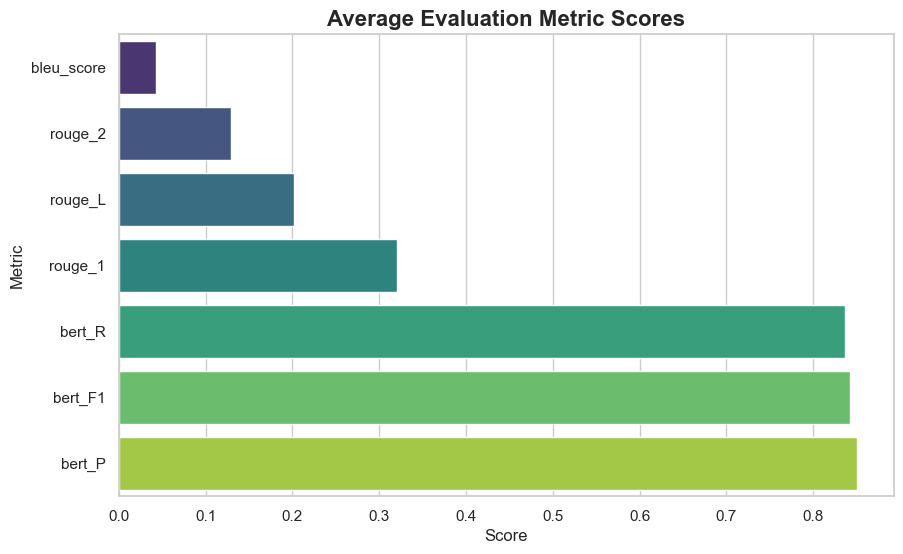

In [ ]:
metric_cols = ['bleu_score', 'rouge_1', 'rouge_2', 'rouge_L', 'bert_P', 'bert_R', 'bert_F1']
avg_scores = df[metric_cols].mean().sort_values()

sns.barplot(x=avg_scores.values, y=avg_scores.index, palette="viridis")
plt.title("Average Evaluation Metric Scores", fontsize=16, fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Metric")
plt.show()


# Metric Distribution Plots

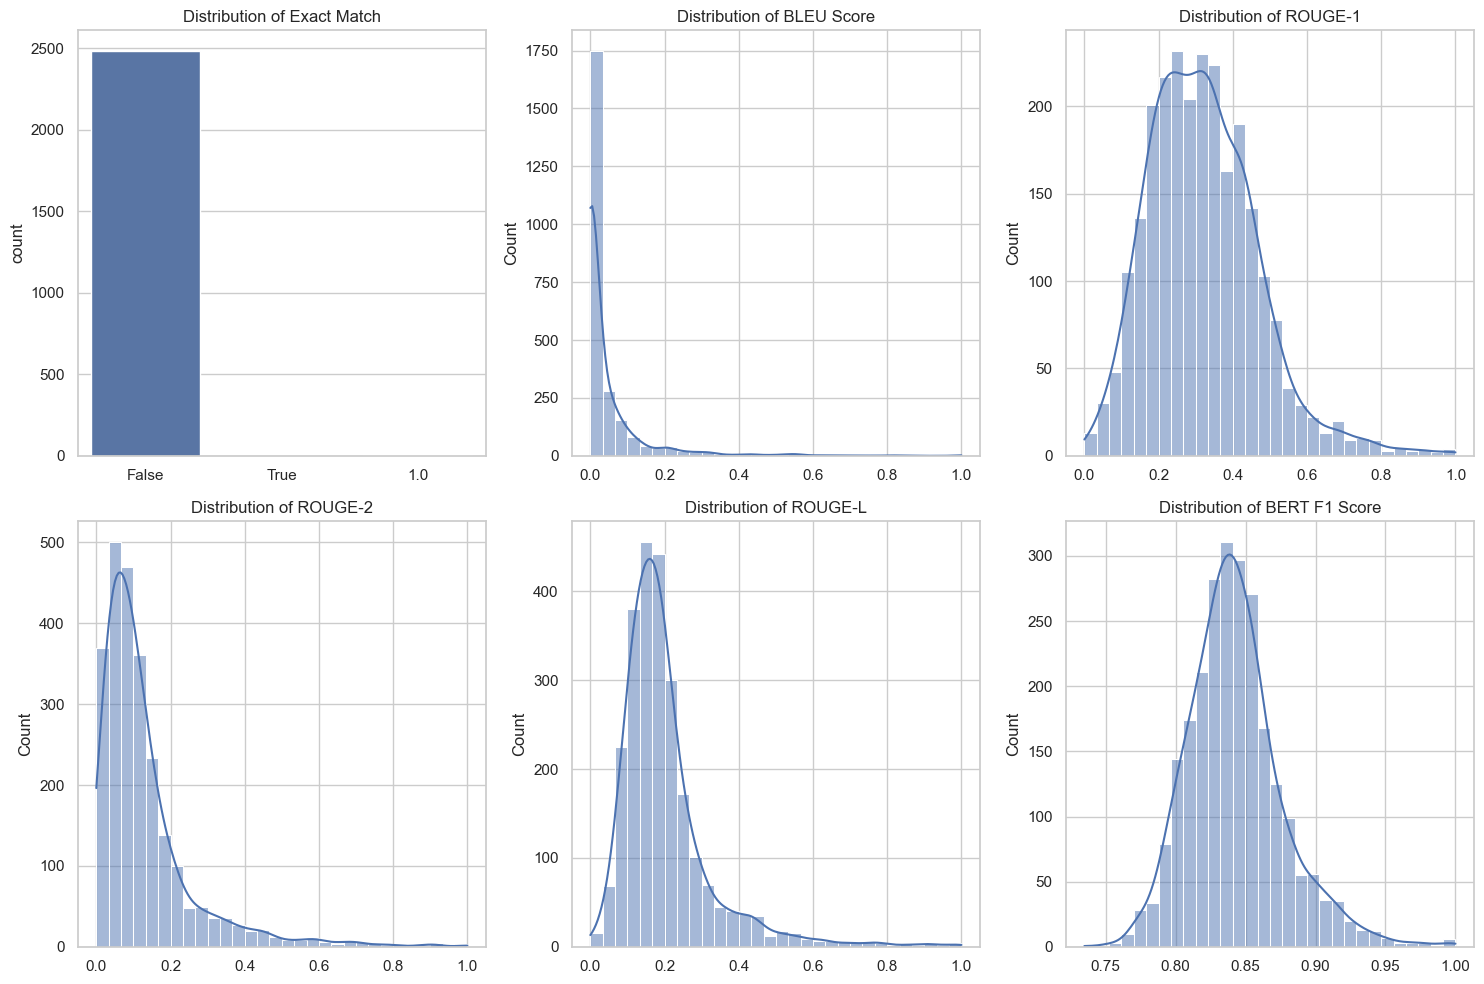

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
plt.figure(figsize=(15, 10))

# Create subplots for each metric
metrics = ['exact_match', 'bleu_score', 'rouge_1', 'rouge_2', 'rouge_L', 'bert_F1']
titles = ['Exact Match', 'BLEU Score', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERT F1 Score']

for i, (metric, title) in enumerate(zip(metrics, titles), 1):
    plt.subplot(2, 3, i)
    if metric == 'exact_match':
        sns.countplot(x=rag_generated_answer_df_final[metric])
    else:
        sns.histplot(rag_generated_answer_df_final[metric], bins=30, kde=True)
    plt.title(f'Distribution of {title}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# Correlation Heatmap of Evaluation Metrics

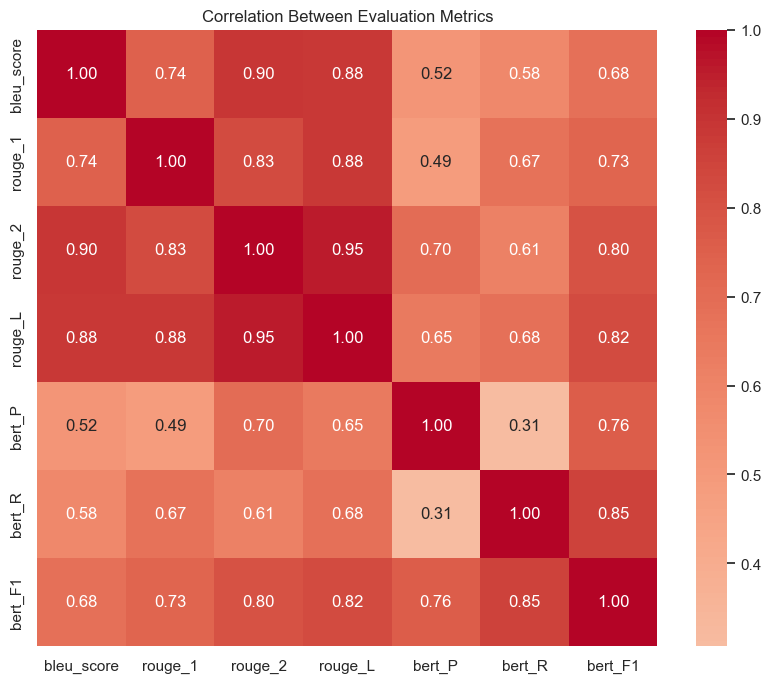

In [ ]:
# Calculate correlations
corr_matrix = rag_generated_answer_df_final[['bleu_score', 'rouge_1', 'rouge_2', 'rouge_L', 'bert_P', 'bert_R', 'bert_F1']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Evaluation Metrics')
plt.show()

# Evaluating Model Performance for Different Healthcare Question Types

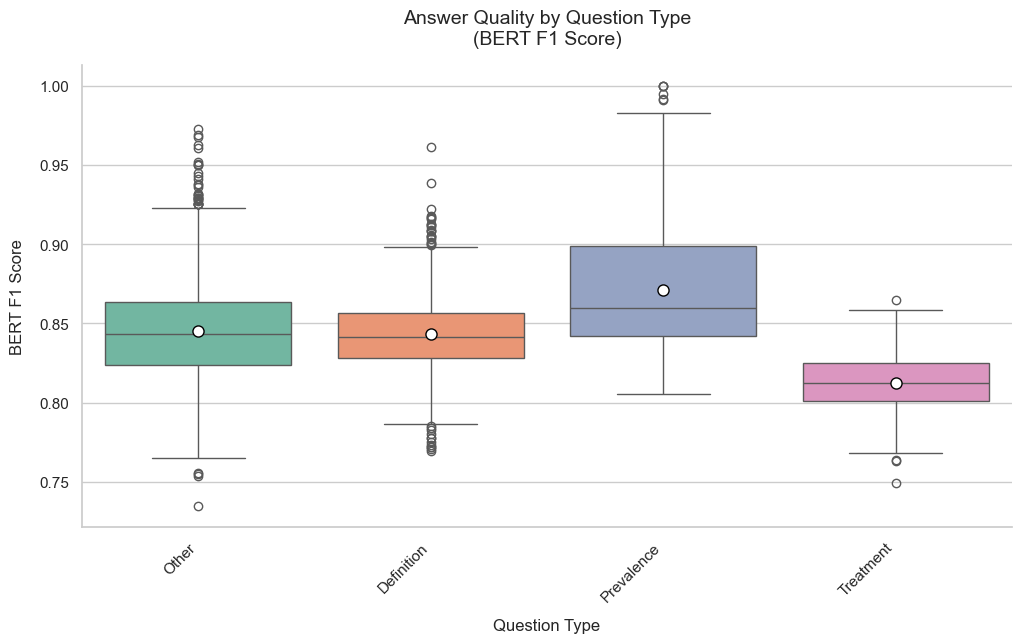

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=rag_generated_answer_df_final,
            x='question_type', y='bert_F1',
            hue='question_type', palette='Set2', showmeans=True,
            meanprops={'marker':'o', 'markerfacecolor':'white',
                      'markeredgecolor':'black', 'markersize':'8'})
plt.title('Answer Quality by Question Type\n(BERT F1 Score)', fontsize=14, pad=15)
plt.xlabel('Question Type', labelpad=10)
plt.ylabel('BERT F1 Score', labelpad=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.show()


# Metric Comparison by Exact Match (Boxplot Grouped)

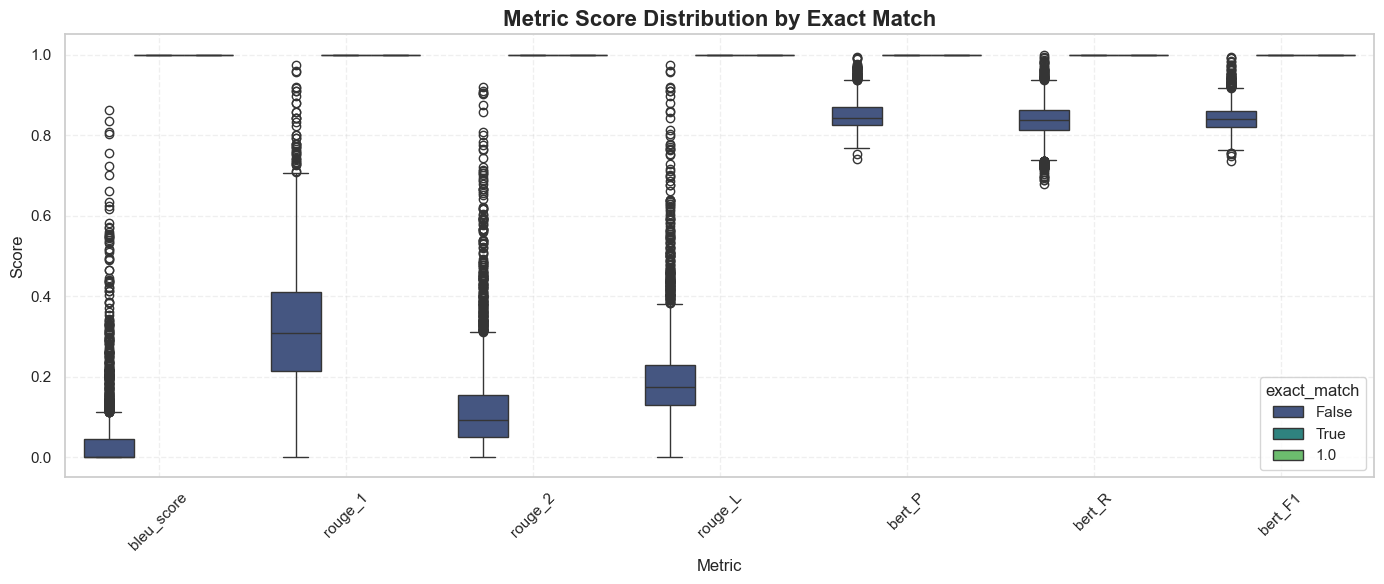

In [ ]:
melted = df.melt(id_vars='exact_match', value_vars=metric_cols, var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.boxplot(data=melted, x='Metric', y='Score', hue='exact_match', palette='viridis')
plt.title("Metric Score Distribution by Exact Match", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Distribution of Mean BERT F1 Scores with Answer Counts by Category

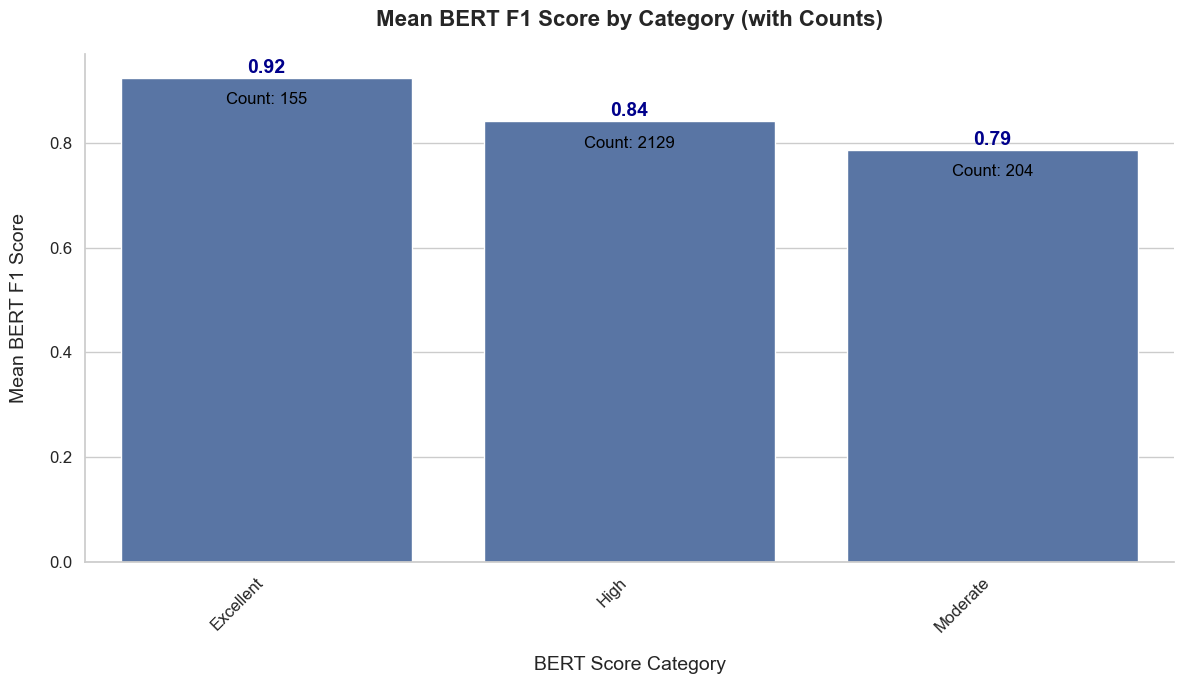

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Classify BERT F1 scores into categories: Moderate, High, Excellent
def categorize_bert_score(bert_score):
    if bert_score < 0.8:
        return 'Moderate'
    elif 0.8 <= bert_score < 0.9:
        return 'High'
    else:
        return 'Excellent'

# Apply the classification to create a new column 'bert_category'
rag_generated_answer_df_final['bert_category'] = rag_generated_answer_df_final['bert_F1'].apply(categorize_bert_score)

# Calculate mean BERT F1 scores and counts for each category (Moderate, High, Excellent)
mean_bert_scores = rag_generated_answer_df_final.groupby('bert_category')['bert_F1'].mean().reset_index()
category_counts = rag_generated_answer_df_final['bert_category'].value_counts().reset_index()
category_counts.columns = ['bert_category', 'count']

# Merge mean scores and counts
mean_bert_scores = mean_bert_scores.merge(category_counts, on='bert_category')

# Plot the bar plot with annotations for both mean scores and counts
plt.figure(figsize=(12, 7))

# Plotting without the deprecated 'ci' argument
bar_plot = sns.barplot(x='bert_category', y='bert_F1', data=mean_bert_scores, errorbar=None)

# Add annotations for mean BERT F1 score values
for i, row in mean_bert_scores.iterrows():
    # Mean score annotation (place it a bit above the bar)
    bar_plot.text(i, row['bert_F1'] + 0.01, f'{row["bert_F1"]:.2f}', ha='center', fontsize=14, fontweight='bold', color='darkblue')
    # Count annotation (place it below the bar)
    bar_plot.text(i, row['bert_F1'] - 0.05, f'Count: {row["count"]}', ha='center', fontsize=12, fontweight='light', color='black')

# Customize plot
plt.title('Mean BERT F1 Score by Category (with Counts)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('BERT Score Category', labelpad=15, fontsize=14)
plt.ylabel('Mean BERT F1 Score', labelpad=15, fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Remove top and right spines for a cleaner look
sns.despine()

# Show plot
plt.show()


# Heatmap of Mean BERT F1 Scores by Question Type and BERT Score Category

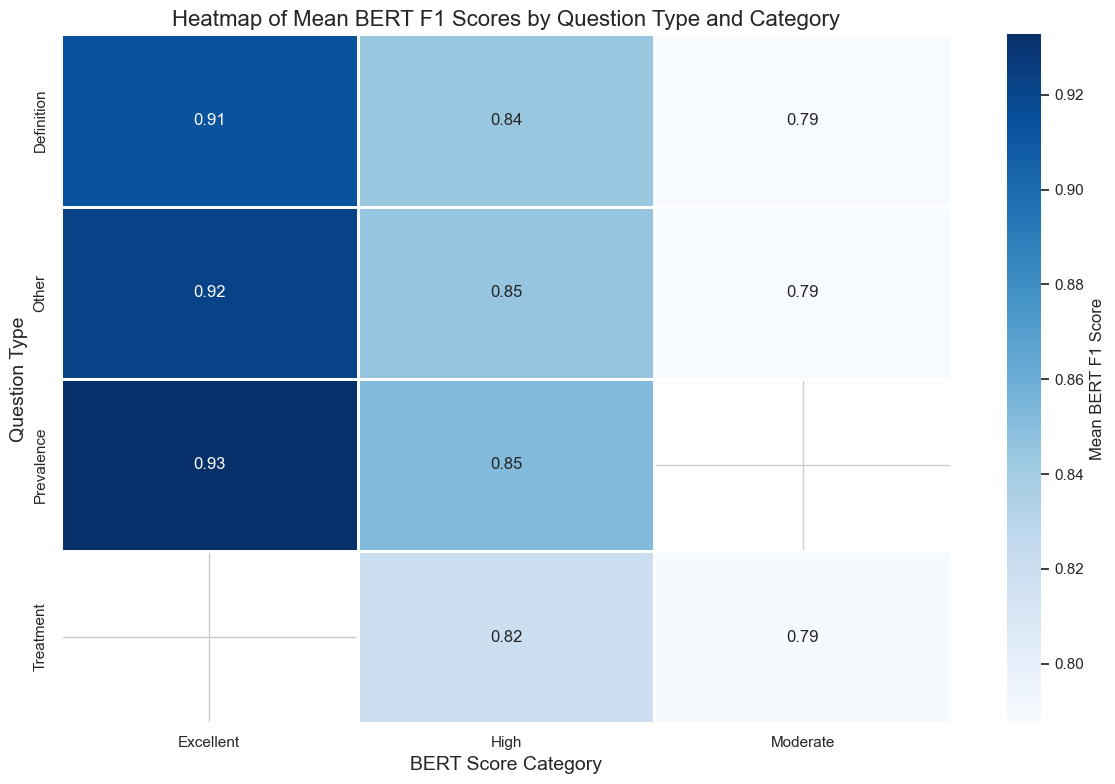

In [ ]:
# Correlation between BERT F1 scores and question types
question_type_bert = rag_generated_answer_df_final.groupby(['question_type', 'bert_category'])['bert_F1'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(question_type_bert, annot=True, fmt='.2f', cmap="Blues", linewidths=1, linecolor='white', cbar_kws={'label': 'Mean BERT F1 Score'})
plt.title('Heatmap of Mean BERT F1 Scores by Question Type and Category', fontsize=16)
plt.xlabel('BERT Score Category', fontsize=14)
plt.ylabel('Question Type', fontsize=14)
plt.tight_layout()
plt.show()
